Step 1: Load the dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/Users/adamkhay/Desktop/Practicum1/vehicles.csv"

df = pd.read_csv(file_path, low_memory=False)

df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


Step 2: Check the size of the dataset

In [4]:
df.shape

(426880, 26)

That means there are 426,880 car listings and 26 columns.

Step 3: View all column names

In [5]:
list(df.columns)

['id',
 'url',
 'region',
 'region_url',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'VIN',
 'drive',
 'size',
 'type',
 'paint_color',
 'image_url',
 'description',
 'county',
 'state',
 'lat',
 'long',
 'posting_date']

Now that we know the columns that we have in our dataset, we can now notice that columns like price, year, odometer, title_status, condition, transmission, fuel, type, and manufacturer are especially important because they describe whether a car may be affordable, reliable, risky, overpriced, or a smart buy.

Step 4: Review column types and missing values quickly

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

From looking at the Non-Null Count, we can see that we have a lot of missing values. 

Numerical columns: id, price, year, odometer, lat, and long
And most other columns are text-based categories: manufacturer, condition, fuel, title_status, transmission, drive, type, and paint_color.

The output also shows that some columns have many missing values. However, condition, cylinders, VIN, drive, size, type, and paint_color have fewer non-null values than the full dataset size. This means they need careful cleaning before analysis.

For my project, the most useful columns are price, year, odometer, manufacturer, condition, fuel, title_status, transmission, and type because they can help measure affordability, mileage risk, age, and buyer regret.


Step 5: Create a missing values table

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(by="missing_percent", ascending=False)

missing_summary 

,missing_count,missing_percent
county,426880,100.000000
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
VIN,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753


County column: (100% missing values) so it should likely be removed or ignored.
Size column: 72% missing, so it is unreliable for the regret-score model unless treated carefully.
Missing values are also in columns: cylinders, condition, VIN, drive, paint_color, and type (these are still be useful because missing information itself can signal listing quality problems) For example, if a seller does not report the car’s condition, that may increase buyer uncertainty
Columns: price, state, region, url, and id have no missing values.
Year, odometer, fuel, transmission, and title_status have low missing percentages, making them strong candidates for the regret-score framework.

Step 6: Visualize missing values

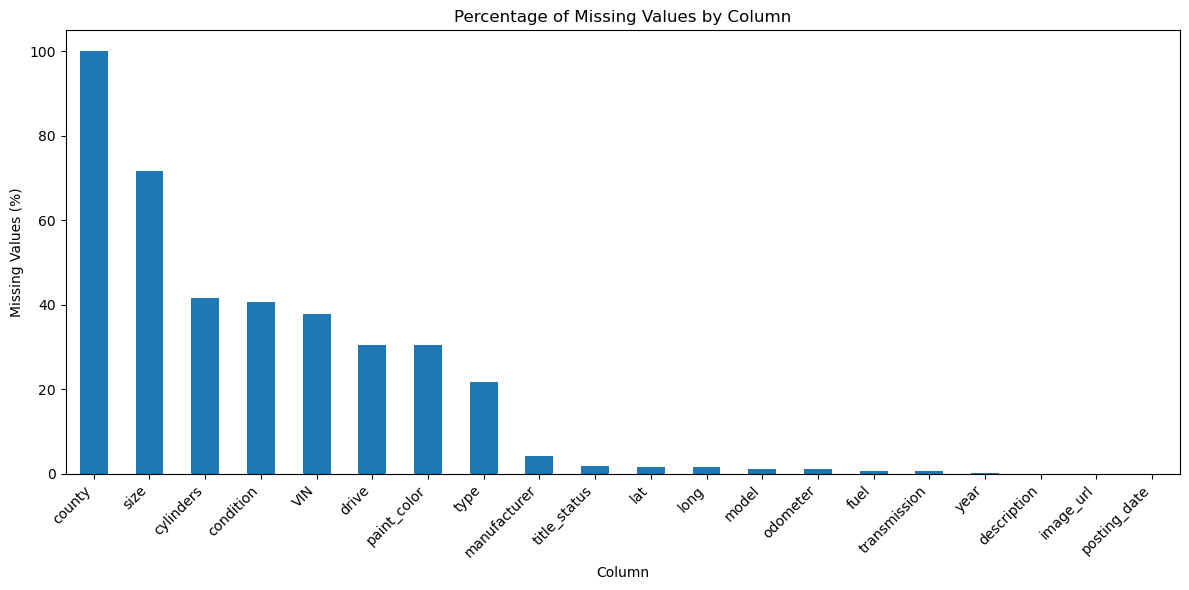

In [8]:
missing_summary[missing_summary["missing_percent"] > 0]["missing_percent"].plot(kind="bar", figsize=(12, 6))

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

here, we observe that "country" is 100% missing values, followed by "size" which contains 71% missing values, then cylinders with 41% missing values. 

Step 7: Check duplicate records

In [9]:
total_duplicates = df.duplicated().sum()

total_duplicates

0

This checks whether the exact same row appears more than once.
Duplicate listings can make the analysis misleading because the same car can be counted multiple times. If duplicates exist, the model can think certain types of cars are more common than they really are.

Step 8: Check duplicates using listing ID, URL, and VIN if available

In [10]:
duplicate_checks = {}

for col in ["id", "url", "VIN"]:
    if col in df.columns:
        duplicate_checks[col] = df[col].duplicated().sum()

duplicate_checks

{'id': 0, 'url': 0, 'VIN': 308615}

"id" and "url" columns have 0 duplicates
"VIN" column has 308,615 duplicate values. But this does not automatically mean 308,615 duplicate cars. This happens because many rows have missing VIN values, and pandas counts repeated missing/blank VINs as duplicates.

Step 9: Review basic statistics for numeric columns

In [11]:
pd.set_option("display.float_format", "{:.2f}".format)

numeric_columns = ["price", "year", "odometer"]

existing_numeric_columns = [col for col in numeric_columns if col in df.columns]

df[existing_numeric_columns].describe()

,price,year,odometer
count,426880.00,425675.00,422480.00
mean,75199.03,2011.24,98043.33
std,12182282.17,9.45,213881.50
min,0.00,1900.00,0.00
25%,5900.00,2008.00,37704.00
50%,13950.00,2013.00,85548.00
75%,26485.75,2017.00,133542.50
max,3736928711.00,2022.00,10000000.00


side note: 

lat (latitude): it tells how far north or south a location is.

long (longitude): it tells how far east or west a location is.


The count row shows how many non-missing values in each column.
The median price is $13,950 while the average car price is $75,199 (that is non-realistic. The maximum price is $3.7 billion (outlier or data entry error).
The average and the median odometer are close (98,043 and 85,548 miles). The max odometer is 10,000,000 miles (unrealistic)

Step 10: Identify unrealistic prices

In [12]:
unrealistic_prices = df[
    (df["price"].isnull()) |
    (df["price"] <= 500) |
    (df["price"] > 150000)
]

unrealistic_prices[["price", "year", "manufacturer", "model", "odometer", "title_status"]].head(20)

,price,year,manufacturer,model,odometer,title_status
10,0,NaN,NaN,NaN,NaN,NaN
11,0,NaN,NaN,NaN,NaN,NaN
12,0,NaN,NaN,NaN,NaN,NaN
13,0,NaN,NaN,NaN,NaN,NaN
14,0,NaN,NaN,NaN,NaN,NaN
26,500,NaN,NaN,NaN,NaN,NaN
46,0,2011.00,jeep,compass,99615.00,clean
96,80,2004.00,honda,NaN,94020.00,clean
126,0,2018.00,chevrolet,express cargo van,68472.00,clean
127,0,2019.00,chevrolet,express cargo van,69125.00,clean


Extremely low prices may represent scams, damaged cars, missing information, or placeholder prices. Extremely high prices may be luxury vehicles, commercial vehicles, or listing errors. These listings should be flagged because they may create bias in the analysis.

Step 11: Count unrealistic price entries

In [13]:
price_issue_count = len(unrealistic_prices)
price_issue_percent = (price_issue_count / len(df)) * 100

price_issue_count, price_issue_percent

(43311, 10.145942653673163)

43,311 listings have suspicious prices and they represent 10.1% of the dataset

Step 12: Identify unrealistic vehicle years

In [14]:
current_year = 2026

unrealistic_years = df[
    (df["year"].isnull()) |
    (df["year"] < 1980) |
    (df["year"] > current_year + 1)
]

unrealistic_years[["price", "year", "manufacturer", "model", "odometer", "title_status"]].head(20)

,price,year,manufacturer,model,odometer,title_status
0,6000,NaN,NaN,NaN,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN
5,1600,NaN,NaN,NaN,NaN,NaN
6,1000,NaN,NaN,NaN,NaN,NaN
7,15995,NaN,NaN,NaN,NaN,NaN
8,5000,NaN,NaN,NaN,NaN,NaN
9,3000,NaN,NaN,NaN,NaN,NaN


In the first 20 results, the year column is missing for every displayed row, and many other important columns are also missing, such as manufacturer, model, odometer, and title_status. This means these listings do not provide enough information to judge the vehicle properly.

Step 13: Identify unrealistic mileage values

In [15]:
unrealistic_mileage = df[
    (df["odometer"].isnull()) |
    (df["odometer"] < 0) |
    (df["odometer"] > 400000)
]

unrealistic_mileage[["price", "year", "manufacturer", "model", "odometer", "title_status"]].head(20)

,price,year,manufacturer,model,odometer,title_status
0,6000,NaN,NaN,NaN,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN
5,1600,NaN,NaN,NaN,NaN,NaN
6,1000,NaN,NaN,NaN,NaN,NaN
7,15995,NaN,NaN,NaN,NaN,NaN
8,5000,NaN,NaN,NaN,NaN,NaN
9,3000,NaN,NaN,NaN,NaN,NaN


the same thing on this one, In the first 20 results, the odometer column is missing for every displayed row, and many other important columns are also missing, such as manufacturer, model, year, and title_status. This means these listings do not provide enough information to judge the vehicle properly.

Step 14: Create a clean inspection copy without deleting the original data

In [16]:
df_inspect = df.copy()

df_inspect.shape

(426880, 26)

I created a copy of the dataset called df_inspect. i did this because I do not want to accidentally damage my origonal dataset. From now on, I can test new columns, flags, and cleaning decisions on df_inspect.

Step 15: Create issue flags for suspicious listings

In [17]:
df_inspect["price_issue"] = (
    (df_inspect["price"].isnull()) |
    (df_inspect["price"] <= 500) |
    (df_inspect["price"] > 150000)
)

df_inspect["year_issue"] = (
    (df_inspect["year"].isnull()) |
    (df_inspect["year"] < 1980) |
    (df_inspect["year"] > 2027)
)

df_inspect["odometer_issue"] = (
    (df_inspect["odometer"].isnull()) |
    (df_inspect["odometer"] < 0) |
    (df_inspect["odometer"] > 400000)
)

df_inspect[["price_issue", "year_issue", "odometer_issue"]].sum()

price_issue       43311
year_issue         9618
odometer_issue     6102
dtype: int64

This creates 3 new columns 

price_issue: cars with suspicious prices, such as $0, very cheap prices, or extremely high prices.

year_issue: cars with missing or unrealistic years.

odometer_issue: cars with missing, negative, or extremely high mileage.


The issue flags help identify listings that may create problems for analysis or may represent higher buyer uncertainty. Instead of immediately deleting these records, I flagged them so they can be studied as part of the regret-score framework. This matters because suspicious values, such as a price of zero, missing year, or missing odometer reading, may signal poor listing quality. For a first-time buyer, incomplete information can increase the chance of regret because the buyer cannot fully judge whether the vehicle is fairly priced, reliable, or risky.

Step 16: Count how many total issues each listing has

In [18]:
df_inspect["total_data_issues"] = (
    df_inspect["price_issue"].astype(int) +
    df_inspect["year_issue"].astype(int) +
    df_inspect["odometer_issue"].astype(int)
)

df_inspect["total_data_issues"].value_counts().sort_index()

total_data_issues
0    371240
1     52295
2      3299
3        46
Name: count, dtype: int64

so, most cars in the dataset have no major issue based on price, year, and mileage. That is great because it means the majority of listings can be used for analysis.

However, 52,295 listings have at least one problem. 3,299 listings have 2 issues, and 46 listings have all 3.

This is useful because listings with more issues should receive more risk in the regret-score framework. A car with missing price, year, and mileage is harder for a buyer to trust 

Step 17: View listings with the most data issues

In [19]:
df_inspect[
    df_inspect["total_data_issues"] >= 2
][[
    "price",
    "year",
    "manufacturer",
    "model",
    "odometer",
    "title_status",
    "price_issue",
    "year_issue",
    "odometer_issue",
    "total_data_issues"
]].head(20)

,price,year,manufacturer,model,odometer,title_status,price_issue,year_issue,odometer_issue,total_data_issues
0,6000,NaN,NaN,NaN,NaN,NaN,False,True,True,2
1,11900,NaN,NaN,NaN,NaN,NaN,False,True,True,2
2,21000,NaN,NaN,NaN,NaN,NaN,False,True,True,2
3,1500,NaN,NaN,NaN,NaN,NaN,False,True,True,2
4,4900,NaN,NaN,NaN,NaN,NaN,False,True,True,2
5,1600,NaN,NaN,NaN,NaN,NaN,False,True,True,2
6,1000,NaN,NaN,NaN,NaN,NaN,False,True,True,2
7,15995,NaN,NaN,NaN,NaN,NaN,False,True,True,2
8,5000,NaN,NaN,NaN,NaN,NaN,False,True,True,2
9,3000,NaN,NaN,NaN,NaN,NaN,False,True,True,2


This shows listings that have at least two major problems.

for my project, these listings are useful because they represent high uncertainty. A buyer cannot confidently judge a car when price, year, or mileage information is missing or suspicious, so these records may later fall into an “avoid” or high-risk category.

Step 18: Create a simple data-quality category

In [20]:
def data_quality_category(issue_count):
    if issue_count == 0:
        return "complete enough"
    elif issue_count == 1:
        return "some concern"
    elif issue_count == 2:
        return "high concern"
    else:
        return "very high concern"

df_inspect["data_quality_category"] = df_inspect["total_data_issues"].apply(data_quality_category)

df_inspect["data_quality_category"].value_counts()

data_quality_category
complete enough      371240
some concern          52295
high concern           3299
very high concern        46
Name: count, dtype: int64

This turns the number of issues into an easier category.
This is useful because later, the regret score can include a data-quality risk factor.

The data-quality category translates technical data issues into buyer-friendly language. This supports the purpose of the project because the final tool is meant to help young buyers, students, and first-time buyers understand risk more clearly.

Step 19: Create a data-quality summary table

In [21]:
data_quality_summary = pd.DataFrame({
    "issue": [
        "Suspicious or missing prices",
        "Suspicious or missing years",
        "Suspicious or missing odometer values"
    ],
    "count": [
        df_inspect["price_issue"].sum(),
        df_inspect["year_issue"].sum(),
        df_inspect["odometer_issue"].sum()
    ]
})

data_quality_summary["percent_of_dataset"] = (
    data_quality_summary["count"] / len(df_inspect)
) * 100

data_quality_summary

,issue,count,percent_of_dataset
0,Suspicious or missing prices,43311,10.15
1,Suspicious or missing years,9618,2.25
2,Suspicious or missing odometer values,6102,1.43


The price is the biggest data-quality problem. About 10.15% of the dataset has suspicious or missing prices, which matters because price is central to deciding whether a car is a smart buy, fair deal, or overpriced.

Year and odometer issues are smaller, but still important. A missing or unrealistic year makes it hard to judge the car’s age, and missing mileage makes it hard to estimate wear-and-tear risk.

this table supports the idea that these issues should be included as warning signals in the regret-score framework.

In [22]:
df['VIN'].value_counts().head(50)

VIN
1FMJU1JT1HEA52352    261
3C6JR6DT3KG560649    235
1FTER1EH1LLA36301    231
5TFTX4CN3EX042751    227
1GCHTCE37G1186784    214
1GTN1TEH5EZ273019    207
3VWF17AT1FM655022    199
JN1AZ4EH8KM420880    198
1FTMF1CP3GKD62143    195
1GTR1WE07DZ143724    194
1GT22REG1GZ401351    180
1G1FF1R79G0140582    172
WMEEJ3BA2DK636540    168
1GCVKREH6GZ228691    167
2GTV2LECXK1123316    160
JA4AP3AU9LU013694    157
WDDTG5CB9FJ051220    156
1GT220CG8CZ231238    151
3TMLU4EN4CM085701    150
JM1NDAC74L0413665    150
1GCNCNEH7HZ118773    149
5TFUM5F13GX069124    145
WBAUP9C53CVL91190    145
JTNKARJE9GJ510268    143
1GCHSCEA7H1203280    143
JTNKARJE4GJ508198    142
1GCNCNEH7HZ206660    138
5TFEY5F15EX169621    137
3GTP1VEC4EG551563    136
1FTEX1CMXDFB16329    132
KNAFX6A8XG5647822    129
1FADP5AU1HL114567    128
2B3CJ7DJ7BH589702    127
5J8YD4H39LL041518    126
1C4BJWFG3HL547853    125
5YJSA1DP8DFP06269    124
2C3CDZBT9LH119053    123
1FTER1EHXLLA66736    121
WVGFK9BP2CD004871    120
1G1YR3DW3B5102190    

Step 20: Create a cleaning copy from the inspected dataset

In [23]:
df_clean = df_inspect.copy()

df_clean.shape

(426880, 31)

This creates a new dataset called df_clean.
df is the original raw dataset, df_inspect is the dataset where we inspected problems, and df_clean is the dataset we will prepare for modeling and risk scoring.

Step 21: Remove the useless county column

In [24]:
if "county" in df_clean.columns:
    df_clean = df_clean.drop(columns=["county"])

df_clean.shape

(426880, 30)

The county column was 100% missing, so it does not help the analysis.
Removing it is safe because it contains no usable information. This is different from deleting rows. We are only removing one empty column.

Step 22: Standardize column names

In [25]:
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(" ", "_")

list(df_clean.columns)

['id',
 'url',
 'region',
 'region_url',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'vin',
 'drive',
 'size',
 'type',
 'paint_color',
 'image_url',
 'description',
 'state',
 'lat',
 'long',
 'posting_date',
 'price_issue',
 'year_issue',
 'odometer_issue',
 'total_data_issues',
 'data_quality_category']

This makes column names cleaner and easier to work with.

Step 23: Standardize categorical text values

In [26]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

df_clean[categorical_columns].head()

,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,vin,drive,size,type,paint_color,image_url,description,state,posting_date,data_quality_category
0,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,az,nan,high concern
1,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,ar,nan,high concern
2,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,fl,nan,high concern
3,https://worcester.craigslist.org/cto/d/west-br...,worcester / central ma,https://worcester.craigslist.org,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,ma,nan,high concern
4,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nc,nan,high concern


Step 24: Turn fake missing text back into real missing values

In [27]:
missing_like_values = ["nan", "none", "null", "", "na", "n/a", "unknown"]

for col in categorical_columns:
    df_clean[col] = df_clean[col].replace(missing_like_values, np.nan)

df_clean[categorical_columns].isnull().sum().sort_values(ascending=False).head(15)

size            306361
cylinders       177678
condition       174104
vin             161043
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5282
fuel              3013
transmission      2556
description         71
posting_date        68
image_url           68
dtype: int64

Step 25: Handle missing categorical values using "unknown"

In [28]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna("unknown")

df_clean[categorical_columns].isnull().sum().sum()

0

For my project, this is better than deleting many rows. If a seller does not provide condition, size, paint color, or VIN, that missing information can still be meaningful. A buyer may feel more risk when a listing has missing information.
So "unknown" becomes a useful category instead of losing the row.

Step 26: Handle missing numeric values carefully

In [29]:
numeric_columns = ["price", "year", "odometer", "lat", "long"]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean[numeric_columns].isnull().sum()

price          0
year        1205
odometer    4400
lat         6549
long        6549
dtype: int64

Step 27: Create missing-value flags before filling numeric values

In [30]:
df_clean["missing_price"] = df_clean["price"].isnull()
df_clean["missing_year"] = df_clean["year"].isnull()
df_clean["missing_odometer"] = df_clean["odometer"].isnull()

df_clean[["missing_price", "missing_year", "missing_odometer"]].sum()

missing_price          0
missing_year        1205
missing_odometer    4400
dtype: int64

Missing-value flags were created before filling numeric values so the dataset could preserve information about which records originally had missing data.

1,205 rows have missing year values.

4,400 rows have missing odometer values.


Step 28: Fill missing numeric values using the median

In [31]:
df_clean["price"] = df_clean["price"].fillna(df_clean["price"].median())
df_clean["year"] = df_clean["year"].fillna(df_clean["year"].median())
df_clean["odometer"] = df_clean["odometer"].fillna(df_clean["odometer"].median())

df_clean[["price", "year", "odometer"]].isnull().sum()

price       0
year        0
odometer    0
dtype: int64

This fills missing numeric values using the median.

now we see that there is 0 missing value in these columns 

The median is better than the average here because the dataset has extreme outliers. For example, I already saw that the maximum price is unrealistically huge. The average can be pulled up by those extreme values, but the median is more stable.

Step 29: Handle duplicate VIN values carefully

In [32]:
vin_counts = df_clean["vin"].value_counts()

repeated_vins = vin_counts[vin_counts > 1]

repeated_vins.head(20)

vin
unknown              161043
1fmju1jt1hea52352       261
3c6jr6dt3kg560649       235
1fter1eh1lla36301       231
5tftx4cn3ex042751       227
1gchtce37g1186784       214
1gtn1teh5ez273019       207
3vwf17at1fm655022       199
jn1az4eh8km420880       198
1ftmf1cp3gkd62143       195
1gtr1we07dz143724       194
1gt22reg1gz401351       180
1g1ff1r79g0140582       172
wmeej3ba2dk636540       168
1gcvkreh6gz228691       167
2gtv2lecxk1123316       160
ja4ap3au9lu013694       157
wddtg5cb9fj051220       156
1gt220cg8cz231238       151
3tmlu4en4cm085701       150
Name: count, dtype: int64

here we can see the number of times each VIN is repeated, and also 161,043 listings do not have a VIN,

Step 30: Create a repeated VIN flag

In [33]:
known_vin_mask = df_clean["vin"] != "unknown"

known_vin_counts = df_clean.loc[known_vin_mask, "vin"].value_counts()

repeated_known_vins = known_vin_counts[known_vin_counts > 1]

df_clean["vin_repeated"] = df_clean["vin"].isin(repeated_known_vins.index)

df_clean["vin_repeated"].value_counts()

vin_repeated
False    239026
True     187854
Name: count, dtype: int64

This code creates a new column called vin_repeated.

This column tells us whether a listing has a real VIN that appears more than once in the dataset.

it tells us that 187,854 listings have a real VIN that appears more than once in the dataset.

We are using known_vin_mask because the dataset has 161,043 unknown VINs. We do not want Python to treat all unknown VINs as the same vehicle. That would be wrong because many different cars simply do not have VIN information.

Step 31: Inspect repeated VIN records before deleting anything

In [34]:
df_clean[df_clean["vin_repeated"] == True][[
    "vin",
    "price",
    "year",
    "manufacturer",
    "model",
    "odometer",
    "title_status",
    "region",
    "state",
    "posting_date",
    "url"
]].sort_values(by=["vin", "posting_date"]).head(50)

,vin,price,year,manufacturer,model,odometer,title_status,region,state,posting_date,url
32544,00000,1,1900.00,unknown,all,100000.00,clean,inland empire,ca,2021-04-28t06:44:51-0700,https://inlandempire.craigslist.org/cto/d/coro...
29955,00000,1,1900.00,unknown,all,100000.00,clean,inland empire,ca,2021-05-04t08:37:19-0700,https://inlandempire.craigslist.org/cto/d/coro...
288401,00000000000000000,12345678,2019.00,chevrolet,unknown,100000.00,clean,akron / canton,oh,2021-04-05t12:26:23-0400,https://akroncanton.craigslist.org/ctd/d/canto...
288400,00000000000000000,12345678,2019.00,chevrolet,unknown,100000.00,clean,akron / canton,oh,2021-04-05t12:28:23-0400,https://akroncanton.craigslist.org/ctd/d/canto...
303644,00000000000000000,12345678,2019.00,chevrolet,unknown,100000.00,clean,youngstown,oh,2021-04-05t12:34:11-0400,https://youngstown.craigslist.org/ctd/d/canton...
180617,00000000000000000,0,2018.00,toyota,highlander limited,29345.00,clean,maine,me,2021-04-15t05:22:28-0400,https://maine.craigslist.org/ctd/d/lisbon-fall...
180517,00000000000000000,0,2017.00,toyota,highlander limited,29345.00,clean,maine,me,2021-04-16t06:38:59-0400,https://maine.craigslist.org/ctd/d/lisbon-fall...
180251,00000000000000000,0,2018.00,toyota,highlander limited,29345.00,clean,maine,me,2021-04-17t17:29:58-0400,https://maine.craigslist.org/ctd/d/lisbon-fall...
180244,00000000000000000,0,2018.00,toyota,highlander limited,29345.00,clean,maine,me,2021-04-18t07:11:30-0400,https://maine.craigslist.org/ctd/d/lisbon-fall...
68014,00000000000000000,45000,1973.00,chevrolet,corvette stingray,65000.00,clean,ventura county,ca,2021-04-18t12:12:33-0700,https://ventura.craigslist.org/ctd/d/sherman-o...


This shows examples of repeated VIN records.

This step is important because repeated VINs do not always mean the data is “bad.” Sometimes the same vehicle may be reposted by a dealer, listed in multiple regions, or updated with a new price.

For my project, repeated VINs are still important because they can bias the analysis. If the same car appears 261 times, it can make that vehicle seem more common than it really is.

Step 32: Flag fake, unknown, or invalid VIN values

In [35]:
df_clean["vin_is_fake_or_unknown"] = (
    (df_clean["vin"] == "unknown") |
    (df_clean["vin"].str.fullmatch(r"0+")) |
    (df_clean["vin"].str.len() != 17)
)

df_clean["vin_is_fake_or_unknown"].value_counts()

vin_is_fake_or_unknown
False    264501
True     162379
Name: count, dtype: int64

This code creates a new column called vin_is_fake_or_unknown.

it tells us that 162,379 listings have a fake, unknown, or invalid VIN

I already noticed that some VINs are not real. Some values were just zeros, like 00000000000000000, and some were too short, like 00000.
A real VIN is 17 characters long. So this step protects the analysis from treating fake VINs as real vehicle identifiers.

Step 33: Create a valid VIN flag

In [36]:
df_clean["vin_is_valid"] = df_clean["vin_is_fake_or_unknown"] == False

df_clean["vin_is_valid"].value_counts()

vin_is_valid
True     264501
False    162379
Name: count, dtype: int64

This creates a column that tells us if the VIN looks valid.

here, it looks like VIN is valid in 264,501 listings 

This is useful because we only want to remove duplicate vehicles when the VIN looks trustworthy. We should not remove rows based on fake VINs.

Step 34: Count duplicate valid VINs only

In [37]:
valid_vin_counts = df_clean.loc[df_clean["vin_is_valid"], "vin"].value_counts()

duplicate_valid_vins = valid_vin_counts[valid_vin_counts > 1]

duplicate_valid_vins.head(20)

vin
1fmju1jt1hea52352    261
3c6jr6dt3kg560649    235
1fter1eh1lla36301    231
5tftx4cn3ex042751    227
1gchtce37g1186784    214
1gtn1teh5ez273019    207
3vwf17at1fm655022    199
jn1az4eh8km420880    198
1ftmf1cp3gkd62143    195
1gtr1we07dz143724    194
1gt22reg1gz401351    180
1g1ff1r79g0140582    172
wmeej3ba2dk636540    168
1gcvkreh6gz228691    167
2gtv2lecxk1123316    160
ja4ap3au9lu013694    157
wddtg5cb9fj051220    156
1gt220cg8cz231238    151
jm1ndac74l0413665    150
3tmlu4en4cm085701    150
Name: count, dtype: int64

This checks repeated VINs again, but only among valid-looking VINs.

This tells us that the duplicate problem is not only caused by fake VINs. Some real-looking VINs are also repeated many times.

Step 35: Create a repeated valid VIN flag

In [38]:
df_clean["valid_vin_repeated"] = df_clean["vin"].isin(duplicate_valid_vins.index)

df_clean["valid_vin_repeated"].value_counts()

valid_vin_repeated
False    239619
True     187261
Name: count, dtype: int64

This creates a new column called valid_vin_repeated.
This column tells us that 187,261 listing have a real-looking VIN that appears more than once.

Step 36: Inspect repeated valid VIN records

In [39]:
df_clean[df_clean["valid_vin_repeated"] == True][[
    "vin",
    "price",
    "year",
    "manufacturer",
    "model",
    "odometer",
    "title_status",
    "region",
    "state",
    "posting_date",
    "url"
]].sort_values(by=["vin", "posting_date"]).head(50)

,vin,price,year,manufacturer,model,odometer,title_status,region,state,posting_date,url
42791,00000000000007846,800,2013.00,unknown,is 250,123456.00,clean,orange county,ca,2021-04-29t16:23:53-0700,https://orangecounty.craigslist.org/ctd/d/hesp...
31770,00000000000007846,800,2013.00,unknown,is 250,123456.00,clean,inland empire,ca,2021-04-29t16:24:43-0700,https://inlandempire.craigslist.org/ctd/d/hesp...
31657,00000000000007846,800,2013.00,unknown,is 250,123456.00,clean,inland empire,ca,2021-04-29t22:56:30-0700,https://inlandempire.craigslist.org/ctd/d/hesp...
42381,00000000000007904,800,2013.00,unknown,tl,1.00,clean,orange county,ca,2021-04-30t20:21:22-0700,https://orangecounty.craigslist.org/ctd/d/hesp...
31242,00000000000007904,2999,2013.00,unknown,tl,1.00,clean,inland empire,ca,2021-04-30t20:26:10-0700,https://inlandempire.craigslist.org/ctd/d/hesp...
179327,00000000000238554,0,2017.00,subaru,xv crosstrek 2.0i limited,107630.00,clean,maine,me,2021-04-23t17:27:58-0400,https://maine.craigslist.org/ctd/d/orrs-island...
178176,00000000000238554,0,2017.00,subaru,xv crosstrek,107630.00,clean,maine,me,2021-04-30t20:57:44-0400,https://maine.craigslist.org/ctd/d/lisbon-fall...
178344,00000000000251600,0,2018.00,jeep,grand cherokee limited 4x4,107040.00,clean,maine,me,2021-04-30t06:18:56-0400,https://maine.craigslist.org/ctd/d/topsham-201...
178179,00000000000251600,0,2018.00,jeep,grand cherokee limited 4x4,107040.00,clean,maine,me,2021-04-30t20:13:00-0400,https://maine.craigslist.org/ctd/d/topsham-201...
180530,00000000000594793,0,2015.00,gmc,sierra 2500hd,130801.00,clean,maine,me,2021-04-15t20:49:08-0400,https://maine.craigslist.org/ctd/d/topsham-201...


Step 36: Improve the VIN validity rule again

In [40]:
df_clean["vin_is_fake_or_unknown"] = (
    (df_clean["vin"] == "unknown") |
    (df_clean["vin"].str.fullmatch(r"0+")) |
    (df_clean["vin"].str.len() != 17) |
    (df_clean["vin"].str.startswith("00000"))
)

df_clean["vin_is_valid"] = df_clean["vin_is_fake_or_unknown"] == False

df_clean[["vin_is_fake_or_unknown", "vin_is_valid"]].value_counts()

vin_is_fake_or_unknown  vin_is_valid
False                   True            264299
True                    False           162581
Name: count, dtype: int64

Earlier, we found that some VINs technically had 17 characters, but they still looked fake because they started with many zeros, such as 00000000000007846.
So now, this rule treats those as suspicious too.

Step 37: Recount duplicate VINs using only truly valid VINs

In [41]:
valid_vin_counts = df_clean.loc[df_clean["vin_is_valid"], "vin"].value_counts()

duplicate_valid_vins = valid_vin_counts[valid_vin_counts > 1]

duplicate_valid_vins.head(20)

vin
1fmju1jt1hea52352    261
3c6jr6dt3kg560649    235
1fter1eh1lla36301    231
5tftx4cn3ex042751    227
1gchtce37g1186784    214
1gtn1teh5ez273019    207
3vwf17at1fm655022    199
jn1az4eh8km420880    198
1ftmf1cp3gkd62143    195
1gtr1we07dz143724    194
1gt22reg1gz401351    180
1g1ff1r79g0140582    172
wmeej3ba2dk636540    168
1gcvkreh6gz228691    167
2gtv2lecxk1123316    160
ja4ap3au9lu013694    157
wddtg5cb9fj051220    156
1gt220cg8cz231238    151
3tmlu4en4cm085701    150
jm1ndac74l0413665    150
Name: count, dtype: int64

Step 38: Create the repeated valid VIN flag again

In [42]:
df_clean["valid_vin_repeated"] = df_clean["vin"].isin(duplicate_valid_vins.index)

df_clean["valid_vin_repeated"].value_counts()

valid_vin_repeated
False    239684
True     187196
Name: count, dtype: int64

so here we can see that 187,196 listings are real-looking VIN that appears more than once.

Step 39: Inspect repeated valid VIN records again

In [43]:
df_clean[df_clean["valid_vin_repeated"] == True][[
    "vin",
    "price",
    "year",
    "manufacturer",
    "model",
    "odometer",
    "title_status",
    "region",
    "state",
    "posting_date",
    "url"
]].sort_values(by=["vin", "posting_date"]).head(50)

,vin,price,year,manufacturer,model,odometer,title_status,region,state,posting_date,url
247314,0000136807z137048,29995,1967.00,chevrolet,el camino,1.00,clean,las vegas,nv,2021-05-01t09:32:02-0700,https://lasvegas.craigslist.org/ctd/d/rosevill...
52710,0000136807z137048,29995,1967.00,chevrolet,el camino,1.00,clean,sacramento,ca,2021-05-03t09:30:45-0700,https://sacramento.craigslist.org/ctd/d/rosevi...
246518,0000136807z137048,29995,1967.00,chevrolet,el camino,1.00,clean,las vegas,nv,2021-05-04t09:32:49-0700,https://lasvegas.craigslist.org/ctd/d/rosevill...
248647,000016ka97b113853,29995,1966.00,unknown,amc rambler,78000.00,clean,las vegas,nv,2021-04-27t09:31:24-0700,https://lasvegas.craigslist.org/ctd/d/rosevill...
11440,000016ka97b113853,29995,1966.00,unknown,amc rambler,78000.00,clean,phoenix,az,2021-05-03t09:32:07-0700,https://phoenix.craigslist.org/cph/ctd/d/rosev...
51611,000016ka97b113853,29995,1966.00,unknown,amc rambler,78000.00,clean,sacramento,ca,2021-05-04t09:32:00-0700,https://sacramento.craigslist.org/ctd/d/rosevi...
84034,0000194379s720581,39950,1969.00,chevrolet,corvette,35042.00,clean,hartford,ct,2021-04-28t17:34:36-0400,https://hartford.craigslist.org/ctd/d/waterbur...
270161,0000194379s720581,39950,1969.00,chevrolet,corvette,35042.00,clean,hudson valley,ny,2021-04-28t17:34:51-0400,https://hudsonvalley.craigslist.org/ctd/d/wate...
86169,0000194379s720581,39950,1969.00,chevrolet,corvette,35042.00,clean,new haven,ct,2021-05-02t18:05:16-0400,https://newhaven.craigslist.org/ctd/d/waterbur...
306960,00001h57v6k460785,24999,1976.00,chevrolet,monte carlo,31638.00,clean,oklahoma city,ok,2021-04-16t11:55:20-0500,https://oklahomacity.craigslist.org/ctd/d/sher...


Now, VINs is more realistic than before.

Step 40: Safely remove duplicate valid VINs

In [44]:
valid_vin_df = df_clean[df_clean["vin_is_valid"] == True].copy()
invalid_or_unknown_vin_df = df_clean[df_clean["vin_is_valid"] == False].copy()

valid_vin_df = valid_vin_df.sort_values(
    by=["vin", "posting_date", "price"],
    ascending=[True, False, True]
)

valid_vin_df = valid_vin_df.drop_duplicates(subset=["vin"], keep="first")

df_clean = pd.concat([valid_vin_df, invalid_or_unknown_vin_df], ignore_index=True)

df_clean.shape

(279784, 37)

We split the data into two groups:

valid_vin_df contains listings with trustworthy VINs.
invalid_or_unknown_vin_df contains listings with unknown, fake, or suspicious VINs.

Then we remove duplicates only from the valid VIN group. Finally, we combine the valid and invalid groups back together.
This protects the dataset because I am not deleting different cars just because they share a fake VIN.


Step 41: Confirm valid VIN duplicates were removed

In [45]:
df_clean.loc[df_clean["vin_is_valid"], "vin"].duplicated().sum()

0

That means each valid VIN appears only once in the cleaned dataset. And duplicate are handled properly

Step 42: Filter extreme price outliers

In [46]:
df_clean = df_clean[
    (df_clean["price"] > 500) &
    (df_clean["price"] <= 150000)
]

df_clean.shape

(250853, 37)

This removes listings with unrealistic prices.

Step 43: Filter unrealistic vehicle years

In [47]:
df_clean = df_clean[
    (df_clean["year"] >= 1980) &
    (df_clean["year"] <= 2027)
]

df_clean.shape

(242903, 37)

This removes records with unrealistic or not-useful vehicle years.

Step 44: Filter unrealistic odometer values

In [48]:
df_clean = df_clean[
    (df_clean["odometer"] >= 0) &
    (df_clean["odometer"] <= 400000)
]

df_clean.shape

(241865, 37)

Step 45: Reset the index after filtering

In [49]:
df_clean = df_clean.reset_index(drop=True)

df_clean.shape

(241865, 37)

This resets the row numbers after duplicate removal and outlier filtering.
When rows are removed, Python keeps the old row numbers. Resetting the index makes the cleaned dataset easier to read and work with.

Step 46: Create vehicle age

In [50]:
current_year = 2026

df_clean["vehicle_age"] = current_year - df_clean["year"]

df_clean[["year", "vehicle_age"]].head()

,year,vehicle_age
0,1980.00,46.00
1,1987.00,39.00
2,2006.00,20.00
3,2009.00,17.00
4,1995.00,31.00


This creates a new column called vehicle_age.
Vehicle age is easier to interpret than just the year.

Step 47: Create mileage risk categories

In [51]:
def mileage_risk_category(odometer):
    if odometer < 50000:
        return "low mileage"
    elif odometer < 100000:
        return "moderate mileage"
    elif odometer < 150000:
        return "high mileage"
    else:
        return "very high mileage"

df_clean["mileage_risk"] = df_clean["odometer"].apply(mileage_risk_category)

df_clean["mileage_risk"].value_counts()

mileage_risk
high mileage         67646
moderate mileage     62119
very high mileage    60019
low mileage          52081
Name: count, dtype: int64

This turns raw mileage into easy categories.
Instead of only showing miles, the dataset can now describe it as high mileage.

Step 48: Create age risk categories

In [52]:
def age_risk_category(vehicle_age):
    if vehicle_age <= 5:
        return "newer used car"
    elif vehicle_age <= 10:
        return "moderately aged"
    elif vehicle_age <= 15:
        return "older car"
    else:
        return "very old car"

df_clean["age_risk"] = df_clean["vehicle_age"].apply(age_risk_category)

df_clean["age_risk"].value_counts()

age_risk
very old car       101591
older car           78383
moderately aged     60652
newer used car       1239
Name: count, dtype: int64

This turns vehicle age into a buyer-friendly category.

Step 49: Create title status risk

In [53]:
def title_risk_category(title_status):
    if title_status == "clean":
        return "low title risk"
    elif title_status in ["rebuilt", "salvage"]:
        return "high title risk"
    elif title_status in ["lien", "missing", "parts only"]:
        return "very high title risk"
    else:
        return "unknown title risk"

df_clean["title_risk"] = df_clean["title_status"].apply(title_risk_category)

df_clean["title_risk"].value_counts()

title_risk
low title risk          227215
high title risk           9729
unknown title risk        3136
very high title risk      1785
Name: count, dtype: int64

This creates a title-risk category.
This is one of the strongest features for the project.

Step 50: Create price-to-odometer relationship

In [54]:
df_clean["price_per_1000_miles"] = df_clean["price"] / ((df_clean["odometer"] / 1000) + 1)

df_clean[["price", "odometer", "price_per_1000_miles"]].head()

,price,odometer,price_per_1000_miles
0,16995,98780.00,170.32
1,62000,753.00,35367.94
2,15000,217000.00,68.81
3,6900,164000.00,41.82
4,2900,160000.00,18.01


This creates a feature called price_per_1000_miles.
This connects price and mileage together.

Step 51: Create price-to-age relationship

In [55]:
df_clean["price_per_year_of_age"] = df_clean["price"] / (df_clean["vehicle_age"] + 1)

df_clean[["price", "vehicle_age", "price_per_year_of_age"]].head()

,price,vehicle_age,price_per_year_of_age
0,16995,46.00,361.60
1,62000,39.00,1550.00
2,15000,20.00,714.29
3,6900,17.00,383.33
4,2900,31.00,90.62


Step 52: Create listing completeness score

In [56]:
important_columns = [
    "price",
    "year",
    "odometer",
    "manufacturer",
    "model",
    "condition",
    "fuel",
    "title_status",
    "transmission",
    "type"
]

available_important_columns = [col for col in important_columns if col in df_clean.columns]

df_clean["missing_important_count"] = 0

for col in available_important_columns:
    if df_clean[col].dtype == "object":
        df_clean["missing_important_count"] += df_clean[col].isin(["unknown"]).astype(int)
    else:
        df_clean["missing_important_count"] += df_clean[col].isnull().astype(int)

df_clean["listing_completeness_score"] = 100 - (
    df_clean["missing_important_count"] / len(available_important_columns) * 100
)

df_clean[["missing_important_count", "listing_completeness_score"]].head()

,missing_important_count,listing_completeness_score
0,1,90.00
1,1,90.00
2,0,100.00
3,0,100.00
4,1,90.00


This measures how complete each listing is.

"missing_important_count" shows how many important details are missing from that listing.
"listing_completeness_score" shows how complete the listing is, from 0 to 100.

A listing with more missing important information gets a lower score. A listing with more complete information gets a higher score.

This matters because buyer regret is not only about the car itself. It is also about how much information the buyer has before making a decision.

I will now save a cleaned version of my dataset 

In [58]:
df_clean.to_csv("/Users/adamkhay/Desktop/Practicum1/vehicles_cleaned.csv", index=False)